# Analysis script for predicting Alzheimer's disease, Mild Cognitive Impariment, and Healthy controls from MRI data.

This script will train six candidate ML pipelines, and identify which I believe will be the best at predicting in the trianing data. The first four candidates were used in previous literature (Rallabandi et al., 2020), the last three are novel candidates. 

The candidates are 

### a priori feature selection + :
### - Nonlinear SVM (RBF) (one vs. rest)
### - Linear SVM
### - Naive Bayes
-----------------
### - PCA + non-linear SVM (RBF)
### - PCA + non-linear SVM (RBF) + control for age + scanner field strength
### - Neural network 


--------- Code begins here -------------

Import data

In [53]:
import numpy as np                # arrays and mathematical functions
import pandas as pd               # dataframes
import matplotlib.pyplot as plt   # plotting

data_pd = pd.read_csv('data.csv') # the complete dataset 

#extract variables from the data, .pop also removes them from the data, allowing for training to occur

age = data_pd.pop("Age")
diagnosis = data_pd.pop("Diagnosis")
fieldStrength = data_pd.pop("FieldStrength")
data_pd.pop("ID") # removes ID as it is unnecessary

# data is the DV, diagnosis is the IV/features

# we need our data and labels in np.array form
data = np.array(data_pd)
diagnosis = np.array(diagnosis)

# this is a pandas PD used to store the results of the models 
results = pd.DataFrame(columns=["Model_name", "Accuracy", "Precision", "AUC_ROC"])

### Splitting data into training and validation, we will use stratified split as we have unequal groups (29% alzhiemers, 51% Mild cognitive impairment, and 29% Healthy control) hence the model will not be biased towards any group.

In [54]:
from sklearn.model_selection import StratifiedShuffleSplit # function for strat. split

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=3)
#single split, where test is 20% 

for i, (training_index, validation_index) in enumerate (sss.split(data, diagnosis)):
    # create split indexes
    # Create training arrays using indexes
    data_training = data[training_index,:]
    diagnosis_training = diagnosis[training_index]

    # Create separate testing arrays
    # Create validation array using indexes
    data_validation = data[validation_index,:]
    diagnosis_validation = diagnosis[validation_index]

### Import libraries needed for all methods used

In [55]:
from sklearn.decomposition import PCA # this reduces the dimensionality of the data 
from sklearn.preprocessing import StandardScaler # neuroimaging data comes with a wide range of values, here we make z scores to deal with this
from sklearn.svm import SVC # Support vector machine
from sklearn.svm import LinearSVC # this is a linear support vector machine
from sklearn.pipeline import make_pipeline  # this puts the differnet ML steps togather in one python entity
from sklearn.model_selection import GridSearchCV # this allows us to test  differnet hyperparameter values and select optimal ML pipeline

-------------------------------------
### PCA + SVM + RBF

### Use grid search: Decide how many PCA components explain most of the data, decide how much regularisation is needed to maximise accurarcy (C), and decide how complex the model will be (Gamma)

In [56]:
scaler = StandardScaler() #scales data into z scores, imaging data often comes in a wide range
NlSVC = SVC(kernel="rbf",probability=True) # proba true allows calculations for the auc-roc

pca = PCA() # reduces dimensionaltiy of data, simplify it 
n_components_range = range(1,21,5) # select first 20 in steps of 5 (5, 10, 15, 20). the first few components should explain most of the data anyway. 

pipeline = make_pipeline(scaler,pca,NlSVC)

parameter_grid = {
    "pca__n_components": n_components_range,
    "svc__gamma": [1, 0.1, 0.01, 0.001], # complexity of decision boundary
    "svc__C": [0.1, 1, 10], #regularisation parameters, lower values are less lenient of error 
    # automatically does ridge regression regularisation, l2, non linear SVC does not do l1
}

# I did not put more possible parameters in the grid as it took too long to process 

#Grid search, 5 fold cross validation, roc_auc scoring
#specify ovr, one vs. rest to allow multiclassification using binary contrasts. e.g. alzheimer's vs. non alzheimer's, mild cognitive impairment vs. non mild cognitive impairment 
grid_search = GridSearchCV(pipeline, parameter_grid, cv=5, scoring='roc_auc_ovr')

# Fit the model with cross-validation
grid_search.fit(data_training, diagnosis_training)

#This took ~ 55 seconds on my computer

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('pca', PCA()),
                                       ('svc', SVC(probability=True))]),
             param_grid={'pca__n_components': range(1, 21, 5),
                         'svc__C': [0.1, 1, 10],
                         'svc__gamma': [1, 0.1, 0.01, 0.001]},
             scoring='roc_auc_ovr')

### Final model via grid search

In [5]:
keys = grid_search.best_params_.keys()

params = []

for i in keys:
    params.append(grid_search.best_params_[i])

print("Number of components: ", params[0], "\nC = ", params[1], "\nGamma = ", params[2])

Number of components:  16 
C =  1 
Gamma =  0.001


### Accuracy measures. Predict validation set, measures of accuracy. AUC ROC, specificity, and sensitivity.

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score

best_model = grid_search.best_estimator_ #extract the best model 

training_pred = best_model.predict(data_training) # use the best model to make predictions of the trianing data
training_accuracy = accuracy_score(diagnosis_training,training_pred) # use those predictions and get a score 

print("\nTraining ROC_AUC score = ", round(grid_search.best_score_,4)) # best score is roc_auc as we specified it in the model 
print("Training accuracy = ", round(training_accuracy,4)) 

Training_confusion_matrix = confusion_matrix(diagnosis_training, training_pred)
print("\nTraining Confusion Matrix\n",Training_confusion_matrix)
print("========================================================================")

validation_pred = best_model.predict(data_validation) #use model to preduct validtion data
validation_pred_proba = best_model.predict_proba(data_validation) # instead of predicitons we get the raw probability values the model derives, that it uses to make predictions

validation_accuracy = accuracy_score(diagnosis_validation,validation_pred) #calculate accuracy
validtion_auc = roc_auc_score(diagnosis_validation, validation_pred_proba,multi_class="ovr") #calcualte roc auc, one vs. rest 
print("Validation ROC-AUC = ", round(validtion_auc,4))
print("Validation Accuracy = ", round(validation_accuracy,4))

weighted_precision_score = precision_score(diagnosis_validation, validation_pred, average='weighted', zero_division=0) # calcualtes precision score, weights scores of different classes based on their size (helps with unbalanced classes)
#we have some classes with zero predicitons, which would have led to a warning. zero_division=0 supresses the warning
print("Precision score", round(weighted_precision_score,4))

validation_confusion_matrix = confusion_matrix(diagnosis_validation, validation_pred)
print("\nValidation Confusion Matrix\n",validation_confusion_matrix)

# Precision recall table PER class 
from sklearn.metrics import classification_report
target_names = ["AD","CN","MCI"]
print(classification_report(diagnosis_validation,validation_pred))

#store results 
results.loc[0] = ["PCA + SVM + RBF", round(validation_accuracy,4), round(weighted_precision_score,4), round(validtion_auc,4)]


Training ROC_AUC score =  0.717
Training accuracy =  0.5313

Training Confusion Matrix
 [[ 27   0 183]
 [  0   0 313]
 [  6   0 542]]
Validation ROC-AUC =  0.6966
Validation Accuracy =  0.5336
Precision score 0.4227

Validation Confusion Matrix
 [[  8   0  44]
 [  0   0  79]
 [  2   0 135]]
              precision    recall  f1-score   support

          AD       0.80      0.15      0.26        52
          CN       0.00      0.00      0.00        79
         MCI       0.52      0.99      0.68       137

    accuracy                           0.53       268
   macro avg       0.44      0.38      0.31       268
weighted avg       0.42      0.53      0.40       268



c:\Users\janus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\janus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\janus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

### Permutation test to check that our accuracy score is significanntly different from chance.

In [ ]:
# Permutation test, see if our accuracy measures occur above change
# i.e. compare our results with a chance distribution
from sklearn.model_selection import permutation_test_score
from sklearn.model_selection import StratifiedKFold

n_perm = 50 # number of permutations: 100
skf = StratifiedKFold(n_splits=5)  #specify stratified cross validtion with 5 folds, as we have an unbalanced dataset

emp_auc, perm_auc, perm_pval = permutation_test_score(best_model, #prediction pipeline
                                                      data_training, # features 
                                                      diagnosis_training, # labels
                                                      scoring="accuracy", # scoring method, didn't use roc_auc as it was not working
                                                      cv=skf, #5 fold cross validation split  
                                                      n_permutations=n_perm) #number of permutations 

print("The p value is: ", perm_pval)
# can take up to 1min to run

The p value is:  0.0196078431372549


--------------------------
## PCA + non-linear SVM (RBF) + accounting for age + scanner

--------------------------
# Fully Connected Neural Network (PyTorch). 
<p style="color:lightgreen"> Input is 292 features, with two hidden layers with 124 neurons each. ReLU present after the two hidden layers.  </p>

This code is mostly adapted from the PyTorch beginner tutorial website. 
https://pytorch.org/tutorials/beginner/basics/intro.html


Import packages needed for Neural networks 

In [58]:
import torch # pytorch, used for the neural network
from torch import nn # neural network (NN)
from torch.utils.data import DataLoader, Dataset # used to load the data into the NN
from sklearn.metrics import roc_auc_score 
from sklearn.metrics import precision_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Converting labels into integers as pytorch requires it

In [59]:
diagnosis_label_numeric = []

for i in range(len(diagnosis)):
    if diagnosis[i] == "CN":
        diagnosis_label_numeric.append(0)
    elif diagnosis[i] == "MCI":
        diagnosis_label_numeric.append(1)
    else:
        diagnosis_label_numeric.append(2)

diagnosis_label_numeric = np.array(diagnosis_label_numeric)

### Split the data via stratified sampling, and scale the data

In [60]:
from sklearn.model_selection import StratifiedShuffleSplit # function for strat. split
from sklearn.preprocessing import StandardScaler

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=3)
#single split, where test is 20% 

for i, (training_index, validation_index) in enumerate (sss.split(data, diagnosis_label_numeric)):
    # create split indexes
    # Create training arrays using indexes
    data_training = data_pd.iloc[training_index,:]
    diagnosis_training = diagnosis_label_numeric[training_index]

    # Create separate testing arrays
    # Create validation array using indexes
    data_validation = data_pd.iloc[validation_index,:]
    diagnosis_validation = diagnosis_label_numeric[validation_index]

# Standardize the data
scaler = StandardScaler()
data_training = scaler.fit_transform(data_training)
data_validation = scaler.transform(data_validation)

### Convert data to NP arrays, then Tensors which is the accepted form of data Neural networks accept 

In [61]:
#convert into np array

train_data_np = np.array(data_training)
val_data_np = np.array(data_validation)

train_labels_np = np.array(diagnosis_training)
val_labels_np = np.array(diagnosis_validation)

# convert to tensors

train_data_tensor = torch.tensor(train_data_np, dtype = torch.float32)
val_data_tensor = torch.tensor(val_data_np, dtype = torch.float32)

train_labels_tensor = torch.tensor(train_labels_np, dtype = torch.long)
val_labels_tensor = torch.tensor(val_labels_np, dtype = torch.long)

### Make custom dataset where the data and labels and labels are merged into one entity, NNs require this structure 

In [62]:
class CustomDataset(Dataset):
    #input data and labels
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __len__(self):
        #length
        return len(self.data)

    def __getitem__(self, index):
        #for datapoint at index, get corresponding label
        return self.data[index], self.labels[index]
 
    
# apply to training and validation sets
training_data = CustomDataset(train_data_tensor, train_labels_tensor)
val_dataset = CustomDataset(val_data_tensor, val_labels_tensor)

### Load custom datasets into the NN using a dataloader in batches of 64 data points (shuffle for randomness)

In [63]:
train_dataloader = DataLoader(training_data, batch_size=64,shuffle=True)
test_dataloader = DataLoader(val_dataset, batch_size=64,shuffle=True)

### Set up NN model

In [64]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            #input 292 features, connects to hiden layer of 124 neurons
            #linear is a linear transformation, turning 292 features to 124 features
            nn.Linear(292, 124),
            #ReLU add non linearity into the model, to allow learning of complex data 
            nn.ReLU(),
            nn.Linear(124, 124),
            nn.ReLU(),
            nn.Linear(124, 3),
        )

    def forward(self, x):
        #during the forward pass, use the above layers, the initial learning phase before backpropogation is used to correct the model parameters
        logits = self.linear_relu_stack(x)
        return logits
        #logits are the raw outputs of the NN 

model = NeuralNetwork()
#save the model structure

### Hyper parameters 

In [65]:
epochs = 200 # iterate over dataset 200 times, larger values led to plateauing in previous tests of the accuracy values, possibly indicating overfitting
batch_size = 64 # send data in batches of 64 
learning_rate = 1e-4 # small amount of learning, to avoid overfitting
decay = 0.05 # decay or L2 regularisation, to avoid overfitting


#this method is differnet from other ML methods as we do a training + validation loop 100 times, not training and validation 5 times
#I am not doing k fold cross validaiton as I don't have the computing power to do this, it would take too long. I have made an educated guess about the hyperparameters


# loss function, cross entropy loss
loss_fn = nn.CrossEntropyLoss()

#optimsation algorithms define how to reduce model error
optimiser = torch.optim.SGD(model.parameters(), lr = learning_rate, weight_decay=decay)
#NN calculate weights and biases for each class per iteration of learning, these are the model.parameters put into the optimiser

### Define training and test/validation loop 

In [66]:
def train_loop(dataloader, model, loss_fn, optimiser):
  #input data, NN, loss, optimiser
    
    for batch, (X,y) in enumerate(dataloader):
      #X is data, Y are labels
  
      #make prediction on training data, which goes into the backpropogation step
      pred = model(X)
      loss = loss_fn(pred, y)

      #backpropogation, going backwards through the NN layers to calculate how to alter the current NN model to reduce error 
      loss.backward()
      optimiser.step()
      
      #resets gradients, gradientsfrom the last batch of data  add up, this stops previous predictions about gradients affecting current predictions 
      optimiser.zero_grad()

      if batch % 64 == 0:
        # every 64, i.e. every batch, show loss
        loss = loss.item()
        
        # >7f is round to 7 characters, f is float
        print(f"loss: {loss:>7f}")

accuracy_over_iterations = [] # store validation accuracy over iterations, used in later plots

def test_loop(dataloader, model, loss_fn):
    
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0 # initialise values of test loss, and correct predictions
    
    #evaluating model with torch.no_grad() ensures no learning occurs during test mode
    #stops gradient calculations
    
    final_predictions = [] # used in calculating precision score later, class predictions
    final_predictions_prob = [] # used in later auc roc calculations, class prediction probabilities
    
    with torch.no_grad():
      for X, y in dataloader: #data and labels
        pred = model(X) # make predictions
        test_loss += loss_fn(pred,y).item() # calculate loss add to test loss
        correct += (pred.argmax(1) == y).type(torch.float).sum().item() # comapred pred to Y, sums correct predictions 
        
        final_predictions.extend(pred.argmax(1).tolist()) # append predictions to list, argmax(1) returns the class with the highest probability
        final_predictions_prob.extend(torch.softmax(pred, dim=1).numpy()) # pred probabilites of classes, soft max converts raw scores to probabilities
        

    test_loss /= num_batches #average loss - test loss = test loss / number of batches
    correct /= size # average no. correct predictions
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    accuracy_over_iterations.append(correct*100) # append accuracy to list
    
    return test_loss, correct, accuracy_over_iterations, final_predictions, final_predictions_prob # return test loss, accuracy, and list of accuracies


### Run training and validation 

In [67]:
for t in range(epochs):
  print(f"Epoch {t+1}\n-------------------------------")
  train_loop(train_dataloader, model, loss_fn, optimiser)
  test_loop(test_dataloader, model, loss_fn)
  
  if t == epochs-1:
    final_test_loss, final_correct, final_accuracy_over_iterations, final_predictions, test_predictions_prob = test_loop(test_dataloader, model, loss_fn)
  
print("Done!")

Epoch 1
-------------------------------
loss: 1.144969
Test Error: 
 Accuracy: 23.9%, Avg loss: 1.132794 

Epoch 2
-------------------------------
loss: 1.150540
Test Error: 
 Accuracy: 23.9%, Avg loss: 1.130290 

Epoch 3
-------------------------------
loss: 1.152392
Test Error: 
 Accuracy: 23.9%, Avg loss: 1.130208 

Epoch 4
-------------------------------
loss: 1.125723
Test Error: 
 Accuracy: 23.9%, Avg loss: 1.127100 

Epoch 5
-------------------------------
loss: 1.150695
Test Error: 
 Accuracy: 23.9%, Avg loss: 1.133728 

Epoch 6
-------------------------------
loss: 1.129708
Test Error: 
 Accuracy: 23.9%, Avg loss: 1.128171 

Epoch 7
-------------------------------
loss: 1.147592
Test Error: 
 Accuracy: 23.9%, Avg loss: 1.131862 

Epoch 8
-------------------------------
loss: 1.156881
Test Error: 
 Accuracy: 23.5%, Avg loss: 1.135682 

Epoch 9
-------------------------------
loss: 1.117532
Test Error: 
 Accuracy: 23.5%, Avg loss: 1.135309 

Epoch 10
----------------------------

### Calculate Accuracy, AUC ROC, and Precision

AUC-ROC: 0.5365
Accuracy:  0.5336
Precision (CN, MCI, and AD respectively): [0.44 0.52 0.31]


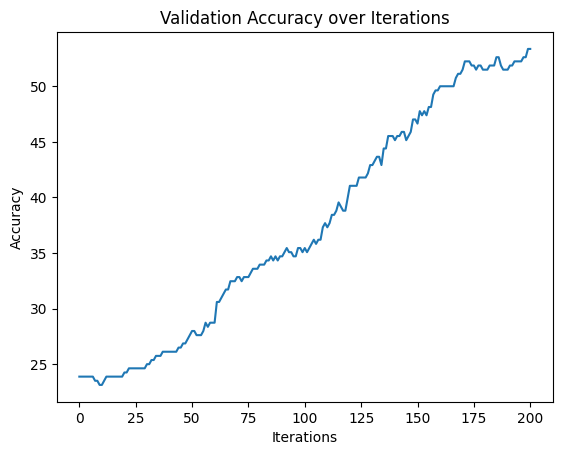

In [ ]:
# Calculate AUC-ROC
auc_roc = roc_auc_score(diagnosis_validation, test_predictions_prob, multi_class='ovr')
print(f"AUC-ROC: {auc_roc:.4f}")
print("Accuracy: ", round(final_correct,4),)

precision_score_value = precision_score(diagnosis_validation, final_predictions, average=None,zero_division=0)
print("Precision (CN, MCI, and AD respectively):", np.round(precision_score_value,2))

plt.plot(accuracy_over_iterations)
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy over Iterations")

results.loc[1] = ["NN", round(final_correct,4),  np.round(precision_score_value,4), round(auc_roc,4)]

--------------------------
## A priori feature selection + Non-linear SVM (RBF) 

<p style="color:lightgreen"> List of a priori features --> hippocampus, amygdala, entorhinal cortex, precuneus, cingulate gyrus, and medial frontal lobe </p>

taken from Grueso, S., Viejo-Sobera, R. Machine learning methods for predicting progression from mild cognitive impairment to Alzheimer’s disease dementia: a systematic review. Alz Res Therapy 13, 162 (2021). https://doi.org/10.1186/s13195-021-00900-w

In [76]:
# corresponding labels for those names above, each area split into 2/3 areas 
areas_list = ["RightPHG", "LeftPHG", "RightHippocampus", "LeftHippocampus","BothHippocampus",
              "RightAmygdala", "LeftAmygdala", "RightEntA", "LeftEntA", "RightPCu", "LeftPCu",
              "RightACg", "LeftACg", "RightMCgG", "LeftMCgG", "RightPCgG", "LeftPCgG", "RightMFC",
              "LeftMFC"]

# reload data, as i was experiencing errors when i did not reload

data_pd = pd.read_csv('data.csv') 
age = data_pd.pop("Age")
diagnosis = data_pd.pop("Diagnosis")
fieldStrength = data_pd.pop("FieldStrength")
data_pd.pop("ID") 

#index the original data using the labels and convert to np array for Machine learning calculations
data_trunc = data_pd[areas_list]
data_trunc = np.array(data_trunc)

# we will then apply the splits, this should not lead to data leakage as we have blindly chosen areas, not chosen areas based on their predictive ability
# i have done this as brain areas are not attatched anymore to the data training/validation
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=3)

for i, (training_index, validation_index) in enumerate (sss.split(data_trunc, diagnosis)):
    
    data_training_trunc = data_trunc[training_index,:]
    diagnosis_training = diagnosis[training_index]

    data_validation_trunc = data_trunc[validation_index,:]
    diagnosis_validation = diagnosis[validation_index]


### Set up pipeline, SVM (RBF)

In [77]:
scaler = StandardScaler() 
SVC_model = SVC(probability=True)

pipeline = make_pipeline(scaler,SVC_model)

#due to the truncated data, (shorter processing time) i have added more parameters
parameter_grid = {
    "svc__kernel": ['rbf',"poly","sigmoid"], # different types of kernels, rbf is default, poly is polynomial, linear is linear
    "svc__gamma": [1, 0.1, 0.01, 0.001,0.0005], 
    "svc__C": [0.001,0.1, 1, 10], 
}

grid_search = GridSearchCV(pipeline, parameter_grid, cv=5, scoring='roc_auc_ovr')

grid_search.fit(data_training_trunc, diagnosis_training)

# 1m 11s

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('svc', SVC(probability=True))]),
             param_grid={'svc__C': [0.001, 0.1, 1, 10],
                         'svc__gamma': [1, 0.1, 0.01, 0.001, 0.0005],
                         'svc__kernel': ['rbf', 'poly', 'sigmoid']},
             scoring='roc_auc_ovr')

In [78]:
keys = grid_search.best_params_.keys()

params = []

for i in keys:
    params.append(grid_search.best_params_[i])

print("C: ", params[0], "\nKernel = ", params[2], "\nGamma = ", params[1])

C:  1 
Kernel =  rbf 
Gamma =  0.01


In [81]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score

best_model = grid_search.best_estimator_ 

training_pred = best_model.predict(data_training_trunc) 
#accuracy
training_accuracy = accuracy_score(diagnosis_training,training_pred) 
#roc_auc
print("\nTraining ROC_AUC score = ", round(grid_search.best_score_,4)) # best score is roc_auc as we specified it in the model 
print("Training accuracy = ", round(training_accuracy,4)) 

Training_confusion_matrix = confusion_matrix(diagnosis_training, training_pred)
print("\nTraining Confusion Matrix\n",Training_confusion_matrix)

print("========================================================================")

validation_pred = best_model.predict(data_validation_trunc) 
validation_pred_proba = best_model.predict_proba(data_validation_trunc) 

#accuracy and roc_auc
validation_accuracy = accuracy_score(diagnosis_validation,validation_pred) 
validtion_auc = roc_auc_score(diagnosis_validation, validation_pred_proba,multi_class="ovr") 
print("Validation ROC-AUC = ", round(validtion_auc,4))
print("Validation Accuracy = ", round(validation_accuracy,4))

#precision 
weighted_precision_score = precision_score(diagnosis_validation, validation_pred, average='weighted', zero_division=0)
print("Precision score", weighted_precision_score)

#confusion matrix 
validation_confusion_matrix = confusion_matrix(diagnosis_validation, validation_pred)
print("\nValidation Confusion Matrix\n",validation_confusion_matrix)

#permutation test
from sklearn.model_selection import StratifiedKFold

n_perm = 100 # number of permutations: 100
skf = StratifiedKFold(n_splits=5)  #specify stratified cross validtion with 5 folds, as we have an unbalanced dataset

# emp_auc, perm_auc, perm_pval = permutation_test_score(best_model, #prediction pipeline
#                                                       data_validation, # features 
#                                                       diagnosis_validation, # labels
#                                                       scoring="roc_auc", # scoring method
#                                                       cv=skf, #5 fold cross validation split  
#                                                       n_permutations=n_perm) #number of permutations 


# Precision recall table PER class 
from sklearn.metrics import classification_report
target_names = ["AD","CN","MCI"]
print(classification_report(diagnosis_validation,validation_pred))

results.loc[2] = ["a priori feature selection + SVM + RBF", round(validation_accuracy,4),  round(weighted_precision_score,4), round(validtion_auc,4)]



Training ROC_AUC score =  0.6927
Training accuracy =  0.5229

Training Confusion Matrix
 [[ 15   0 195]
 [  0   0 313]
 [  3   0 545]]
Validation ROC-AUC =  0.6858
Validation Accuracy =  0.5149
Precision score 0.39170186801839857

Validation Confusion Matrix
 [[  2   0  50]
 [  0   0  79]
 [  1   0 136]]
              precision    recall  f1-score   support

          AD       0.67      0.04      0.07        52
          CN       0.00      0.00      0.00        79
         MCI       0.51      0.99      0.68       137

    accuracy                           0.51       268
   macro avg       0.39      0.34      0.25       268
weighted avg       0.39      0.51      0.36       268



c:\Users\janus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\janus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\janus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

--------------------------
## A priori feature selection + linear SVM

### Since linear SVC can handle L1 and L2 regularisation, we will try both and select the best. we will choose which is best via accuracy scores as linearSVC(), the function does not really do roc auc

### First is L2

In [80]:
# l2 version
scaler = StandardScaler() 
SVC_model = SVC(kernel="linear",probability=True)

pipelinel2 = make_pipeline(scaler,SVC_model)

parameter_grid = {
    "svc__gamma": [1, 0.1, 0.01, 0.001], 
    "svc__C": [0.1, 1, 10], 
    'svc__class_weight': [None, 'balanced']
}

grid_searchl2 = GridSearchCV(pipelinel2, parameter_grid, cv=5, scoring='accuracy')

grid_searchl2.fit(data_training_trunc, diagnosis_training)

# 1m 8s

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('svc',
                                        SVC(kernel='linear',
                                            probability=True))]),
             param_grid={'svc__C': [0.1, 1, 10],
                         'svc__class_weight': [None, 'balanced'],
                         'svc__gamma': [1, 0.1, 0.01, 0.001]},
             scoring='accuracy')

In [7]:
keys = grid_searchl2.best_params_.keys()

params = []

for i in keys:
    params.append(grid_searchl2.best_params_[i])

print("Gamma: ", params[0], "\nC = ", params[2], "\nClass Weight = ", params[1])

Gamma:  10 
C =  1 
Class Weight =  None


### L1

In [ ]:
scaler = StandardScaler() 
SVC_model = LinearSVC(penalty="l2",dual=False,multi_class="ovr")
# dual false as we have more samples than features, one vs. rest, C taken from the above grid search 

pipelinel1 = make_pipeline(scaler,SVC_model)

parameter_grid = {
    "linearsvc__C": [0.1, 1, 2],
    'linearsvc__class_weight': [None, 'balanced']
    # Linear svc does not have a gamma parameter
}

grid_searchl1 = GridSearchCV(pipelinel1, parameter_grid, cv=5, scoring='accuracy') # accuracy as linear SVC does not allow roc auc

grid_searchl1.fit(data_training_trunc, diagnosis_training)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('linearsvc', LinearSVC(dual=False))]),
             param_grid={'linearsvc__C': [0.1, 1, 2],
                         'linearsvc__class_weight': [None, 'balanced']},
             scoring='accuracy')

In [9]:
keys = grid_searchl1.best_params_.keys()

params = []

for i in keys:
    params.append(grid_searchl1.best_params_[i])

print("C: ", params[0], "\nClass Weight = ", params[1])

C:  1 
Class Weight =  None


In [ ]:
# as l1 Linear svc does not make prediction probabilties normally, we will compare accuracy and precision scores only 
# Looked like L2 had the better metrics, hence it will be compared to the other models
# skipped the training accuracy as it is not needed

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score

best_modell1 = grid_searchl1.best_estimator_ 
best_modell2 = grid_searchl2.best_estimator_ 

print("============ Validation Data ============")

validation_predl1 = best_modell1.predict(data_validation_trunc) 
validation_predl2 = best_modell2.predict(data_validation_trunc) 

# accuracy 
validation_accuracyl1 = accuracy_score(diagnosis_validation,validation_predl1) 
print("L1 Validation Accuracy = ", round(validation_accuracyl1,4))
validation_accuracyl2 = accuracy_score(diagnosis_validation,validation_predl2) 
print("L2 Validation Accuracy = ", round(validation_accuracyl2,4))

# precision
weighted_precision_scorel1 = precision_score(diagnosis_validation, validation_predl1, average='weighted', zero_division=0)
print("\nL1 Precision score", weighted_precision_scorel1)
weighted_precision_scorel2 = precision_score(diagnosis_validation, validation_predl2, average='weighted', zero_division=0)
print("L2 Precision score", weighted_precision_scorel2)

# confusion matrix
validation_confusion_matrixl1 = confusion_matrix(diagnosis_validation, validation_predl1)
print("\nL1 Validation Confusion Matrix\n",validation_confusion_matrixl1)
validation_confusion_matrixl2 = confusion_matrix(diagnosis_validation, validation_predl2)
print("\nL2 Validation Confusion Matrix\n",validation_confusion_matrixl2)

# Precision recall table PER class
from sklearn.metrics import classification_report
target_names = ["AD","CN","MCI"]
print(classification_report(diagnosis_validation,validation_predl1))
print("\n")
print(classification_report(diagnosis_validation,validation_predl2))

results.loc[3] = ["a priori feature selection + SVM + linear + L2", round(validation_accuracyl2,4),  round(weighted_precision_scorel2,4), None]

============ Validation Data ============
L1 Validation Accuracy =  0.4664
L2 Validation Accuracy =  0.541

L1 Precision score 0.4384257141130668
L2 Precision score 0.4633897818599311

L1 Validation Confusion Matrix
 [[ 10   4  38]
 [  0  11  68]
 [  9  24 104]]

L2 Validation Confusion Matrix
 [[  8   0  44]
 [  0   0  79]
 [  0   0 137]]
              precision    recall  f1-score   support

          AD       0.53      0.19      0.28        52
          CN       0.28      0.14      0.19        79
         MCI       0.50      0.76      0.60       137

    accuracy                           0.47       268
   macro avg       0.43      0.36      0.36       268
weighted avg       0.44      0.47      0.42       268



              precision    recall  f1-score   support

          AD       1.00      0.15      0.27        52
          CN       0.00      0.00      0.00        79
         MCI       0.53      1.00      0.69       137

    accuracy                           0.54       268
   

c:\Users\janus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\janus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\janus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [ ]:
#permutation test
from sklearn.model_selection import StratifiedKFold

n_perm = 100 # number of permutations: 100
skf = StratifiedKFold(n_splits=5)  #specify stratified cross validtion with 5 folds, as we have an unbalanced dataset

emp_auc, perm_auc, perm_pval = permutation_test_score(best_model, #prediction pipeline
                                                      data_validation, # features 
                                                      diagnosis_validation, # labels
                                                      scoring="roc_auc", # scoring method
                                                      cv=skf, #5 fold cross validation split  
                                                      n_permutations=n_perm) #number of permutations 


# Precision recall table PER class 
from sklearn.metrics import classification_report
target_names = ["AD","CN","MCI"]
print(classification_report(diagnosis_validation,validation_pred))


Training ROC_AUC score =  0.6994
Training accuracy =  0.4883

Training Confusion Matrix
 [[155  25  30]
 [ 43 220  50]
 [178 222 148]]
Validation ROC-AUC =  0.6824
Validation Accuracy =  0.459
Precision score 0.48521344171997155

Validation Confusion Matrix
 [[34  8 10]
 [ 4 55 20]
 [46 57 34]]
              precision    recall  f1-score   support

          AD       0.40      0.65      0.50        52
          CN       0.46      0.70      0.55        79
         MCI       0.53      0.25      0.34       137

    accuracy                           0.46       268
   macro avg       0.46      0.53      0.46       268
weighted avg       0.49      0.46      0.43       268



--------------------------
## Gaussian Naive Bayes


In [83]:
#import gaussian naive bayes, gaussian as we have continuous data and not categorial 
#i tried grid search gaussian naive bayes searching for the best smoothing hyperparameter, which led to worse results than a gaussian NB without the hyperparameter
# hence i did not use grid search for this method
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline  
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()
gnb = GaussianNB()

pipe = make_pipeline(scaler,gnb)
pipe.fit(data_training,diagnosis_training)
y_pred = pipe.predict(data_validation)

print("============ Validation Data ============")

validation_accuracy = accuracy_score(diagnosis_validation,y_pred)
print("\nAccuracy: ", round(validation_accuracy,4))
weighted_precision_score = precision_score(diagnosis_validation, y_pred, average='weighted', zero_division=0)
print("\nPrecision: ", weighted_precision_score)

validation_pred_proba = pipe.predict_proba(data_validation)
validtion_auc = roc_auc_score(diagnosis_validation, validation_pred_proba,multi_class="ovr") 
print("Validation ROC-AUC: ", round(validtion_auc,4))

validation_confusion_matrix = confusion_matrix(diagnosis_validation, y_pred)
print("\nValidation Confusion Matrix\n\n",validation_confusion_matrix)

from sklearn.metrics import classification_report
target_names = ["AD","CN","MCI"]
print(classification_report(diagnosis_validation,y_pred))

results.loc[3] = ["Gaussian Naive Bayes", round(validation_accuracy,4),  round(weighted_precision_score,4), round(validtion_auc,4)]

============ Validation Data ============

Accuracy:  0.2836

Precision:  0.3650810744073749
Validation ROC-AUC:  0.4699

Validation Confusion Matrix

 [[21 16 15]
 [37 24 18]
 [61 45 31]]
              precision    recall  f1-score   support

          AD       0.18      0.40      0.25        52
          CN       0.28      0.30      0.29        79
         MCI       0.48      0.23      0.31       137

    accuracy                           0.28       268
   macro avg       0.31      0.31      0.28       268
weighted avg       0.37      0.28      0.29       268



In [84]:
results

,Model_name,Accuracy,Precision,AUC_ROC
0,PCA + SVM + RBF,0.5336,0.4227,0.6966
1,NN,0.5336,"[0.4444, 0.5185, 0.3125]",0.5365
2,a priori feature selection + SVM + RBF,0.5149,0.3917,0.6858
3,Gaussian Naive Bayes,0.2836,0.3651,0.4699
